In [1]:
import pandas as pd
import glob
import os
import warnings
warnings.filterwarnings("ignore")
# Read all CSV files inside the 'csv' folder
files = glob.glob("csv/*.csv")

print(files)   # Check the files found

df = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)

print(df.shape)

['csv\\Alibaba.csv', 'csv\\Aliexpress.csv', 'csv\\Amazon shopping.csv', 'csv\\Daraz Online Shopping App.csv', 'csv\\Flipkart.csv', 'csv\\Lazada.csv', 'csv\\Meesho.csv', 'csv\\Myntra.csv', 'csv\\Shein.csv', 'csv\\Snapdeal.csv', 'csv\\Walmart.csv']
(630000, 8)


In [2]:
df.columns

Index(['reviewId', 'content', 'score', 'thumbsUpCount', 'at', 'replyContent',
       'repliedAt', 'appName'],
      dtype='object')

In [3]:
df.describe()

,score,thumbsUpCount,at,repliedAt
count,630000.000000,630000.000000,6.300000e+05,1.664880e+05
mean,3.211883,12.252717,1.639047e+12,1.658791e+12
std,1.794616,216.856481,5.555587e+10,5.563957e+10
min,1.000000,0.000000,1.536759e+12,1.386955e+12
25%,1.000000,0.000000,1.594215e+12,1.633535e+12
50%,4.000000,0.000000,1.637215e+12,1.669120e+12
75%,5.000000,1.000000,1.688489e+12,1.709565e+12
max,5.000000,34774.000000,1.723923e+12,1.723829e+12


In [4]:
df.isnull().sum()

reviewId              0
content               1
score                 0
thumbsUpCount         0
at                    0
replyContent     463512
repliedAt        463512
appName               0
dtype: int64

In [5]:
#replyContent and repliedAt have almost all values missing and are not useful for sentiment analysis.
df.drop(columns=['replyContent', 'repliedAt'], inplace=True)

In [6]:
df.columns

Index(['reviewId', 'content', 'score', 'thumbsUpCount', 'at', 'appName'], dtype='object')

In [7]:
#for removing nun in content
df.dropna(subset=['content'], inplace=True)

In [8]:
# Check Duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# if duplicates exist
# df.drop_duplicates(inplace=True)

In [10]:
# Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 629999 entries, 0 to 629999
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   reviewId       629999 non-null  object
 1   content        629999 non-null  object
 2   score          629999 non-null  int64 
 3   thumbsUpCount  629999 non-null  int64 
 4   at             629999 non-null  int64 
 5   appName        629999 non-null  object
dtypes: int64(3), object(3)
memory usage: 33.6+ MB


In [11]:
df['at'] = pd.to_datetime(df['at'], unit='ms')

In [12]:
df['at'].head()

0   2024-07-14 22:21:57
1   2024-07-09 05:12:38
2   2024-07-25 00:12:51
3   2021-01-25 10:11:00
4   2018-12-22 00:25:23
Name: at, dtype: datetime64[ns]

In [13]:
# Create Sentiment Labels
def sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['score'].apply(sentiment)

In [14]:
df['Sentiment'].value_counts()

Sentiment
Positive    335358
Negative    254455
Neutral      40186
Name: count, dtype: int64

In [15]:
df[['content','score','Sentiment']].head()

,content,score,Sentiment
0,Trying to use the on website is almost impossi...,1,Negative
1,Had to uninstall due to the amount of notifica...,3,Neutral
2,I order and it takes too long the shpping days...,1,Negative
3,Buyer beware! They have tons of listings that ...,1,Negative
4,It's all around a great app except for the fac...,4,Positive


In [16]:
print(df["score"].unique())
print(sorted(df["score"].unique()))

[1 3 4 2 5]
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [17]:
print(df["score"].value_counts().sort_index())

score
1    218286
2     36169
3     40186
4     64487
5    270871
Name: count, dtype: int64


In [18]:
# Clean Review Text
import re
def clean_text(text):
    text = text.lower()#Converts the value to a string and all letters to lowercase.
    text = re.sub(r"http\S+", "", text)# Remove url's.
    text = re.sub(r"[^a-zA-Z ]", "", text)# Removes numbers, punctuation, emojis, and special characters.
    text = re.sub(r"\s+", " ", text)# Replaces multiple spaces with a single space.
    return text.strip()# Removes spaces at the beginning and end.
df['clean_review'] = df['content'].apply(clean_text)

In [19]:
df[['clean_review','score','Sentiment']].head()

,clean_review,score,Sentiment
0,trying to use the on website is almost impossi...,1,Negative
1,had to uninstall due to the amount of notifica...,3,Neutral
2,i order and it takes too long the shpping days...,1,Negative
3,buyer beware they have tons of listings that a...,1,Negative
4,its all around a great app except for the face...,4,Positive


In [20]:
# Remove Empty reviews
df = df[df['clean_review'] != ""]

In [21]:
df['clean_review'].isnull().sum()

np.int64(0)

In [22]:
# column containing the number of words in each review
df['word_count'] = df['clean_review'].apply(lambda x: len(str(x).split()))
df['word_count'].head()

0    72
1    58
2    93
3    87
4    73
Name: word_count, dtype: int64

In [23]:
# Remove stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
df['clean_review'] = df['clean_review'].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
# Lemmataization
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['clean_review'] = df['clean_review'].apply(
    lambda x: " ".join(lemmatizer.lemmatize(word) for word in x.split())
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [25]:
# Basic EDA
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

In [26]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 629916 entries, 0 to 629999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   reviewId       629916 non-null  object        
 1   content        629916 non-null  object        
 2   score          629916 non-null  int64         
 3   thumbsUpCount  629916 non-null  int64         
 4   at             629916 non-null  datetime64[ns]
 5   appName        629916 non-null  object        
 6   Sentiment      629916 non-null  object        
 7   clean_review   629916 non-null  object        
 8   word_count     629916 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 48.1+ MB


In [27]:
df.shape

(629916, 9)

In [28]:
df.describe()

,score,thumbsUpCount,at,word_count
count,629916.000000,629916.000000,629916,629916.000000
mean,3.211790,12.254323,2021-12-09 09:35:27.447730688,29.567255
min,1.000000,0.000000,2018-09-12 13:31:47,1.000000
25%,1.000000,0.000000,2020-07-08 12:11:23.500000,9.000000
50%,4.000000,0.000000,2021-11-18 03:24:25.500000,22.000000
75%,5.000000,1.000000,2023-07-04 15:29:58.750000128,43.000000
max,5.000000,34774.000000,2024-08-17 19:29:45,382.000000
std,1.794619,216.870895,NaN,24.963932


In [29]:
df.head()

,reviewId,content,score,thumbsUpCount,at,appName,Sentiment,clean_review,word_count
0,275f465b-a58b-439e-ae7c-f9f6dcf2634d,Trying to use the on website is almost impossi...,1,39,2024-07-14 22:21:57,Alibaba,Negative,trying use website almost impossible due app s...,72
1,e6c13852-277e-451a-b8d5-dd92aea75402,Had to uninstall due to the amount of notifica...,3,60,2024-07-09 05:12:38,Alibaba,Neutral,uninstall due amount notification ill likely r...,58
2,254b3705-c54b-4ce4-8982-5b468d38231d,I order and it takes too long the shpping days...,1,7,2024-07-25 00:12:51,Alibaba,Negative,order take long shpping day saw date shipping ...,93
3,c83c1e64-6aa3-42e8-9a56-0385a297b87b,Buyer beware! They have tons of listings that ...,1,2301,2021-01-25 10:11:00,Alibaba,Negative,buyer beware ton listing allow place item cart...,87
4,7a65dce8-3f09-4e4e-a263-55efebc13c65,It's all around a great app except for the fac...,4,1859,2018-12-22 00:25:23,Alibaba,Positive,around great app except face cannot send file ...,73


In [30]:
# missing Values
df.isnull().sum()

reviewId         0
content          0
score            0
thumbsUpCount    0
at               0
appName          0
Sentiment        0
clean_review     0
word_count       0
dtype: int64

In [31]:
# Check Duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


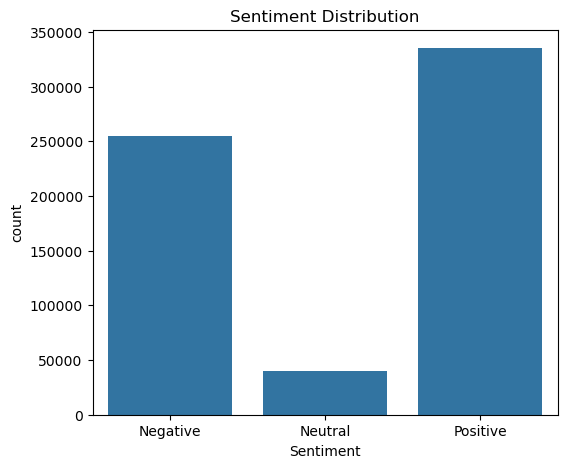

In [32]:
plt.figure(figsize=(6,5))
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

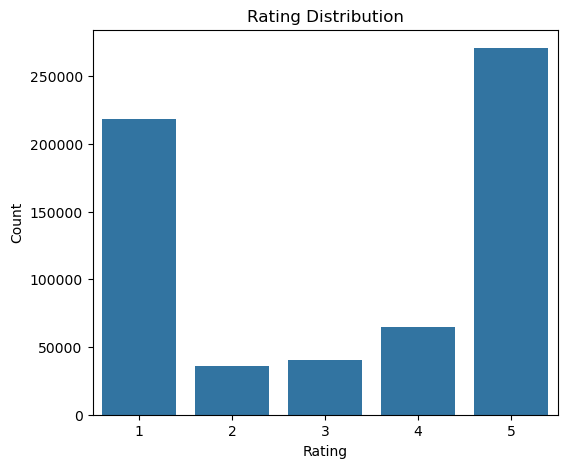

In [33]:
# rating Distibution
plt.figure(figsize=(6,5))
sns.countplot(x='score', data=df)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [34]:
df['Review_Length'] = df['clean_review'].apply(len)

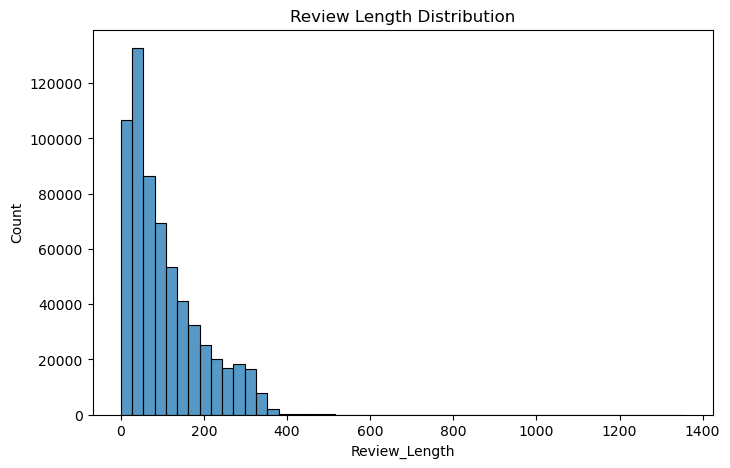

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['Review_Length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

In [36]:
# Most Frequent Words
from collections import Counter

text = " ".join(df['clean_review'].astype(str))

words = text.split()

word_freq = Counter(words)

word_freq.most_common(20)

[('app', 300550),
 ('product', 167152),
 ('good', 137358),
 ('order', 135422),
 ('item', 111978),
 ('time', 108554),
 ('delivery', 94227),
 ('customer', 81283),
 ('service', 78076),
 ('get', 74368),
 ('shopping', 74346),
 ('dont', 73881),
 ('price', 63253),
 ('great', 61462),
 ('use', 60095),
 ('love', 60044),
 ('like', 58955),
 ('one', 56000),
 ('amazon', 53444),
 ('even', 51752)]

In [37]:
# word Count
df['Word_Count'] = df['clean_review'].apply(lambda x: len(str(x).split()))

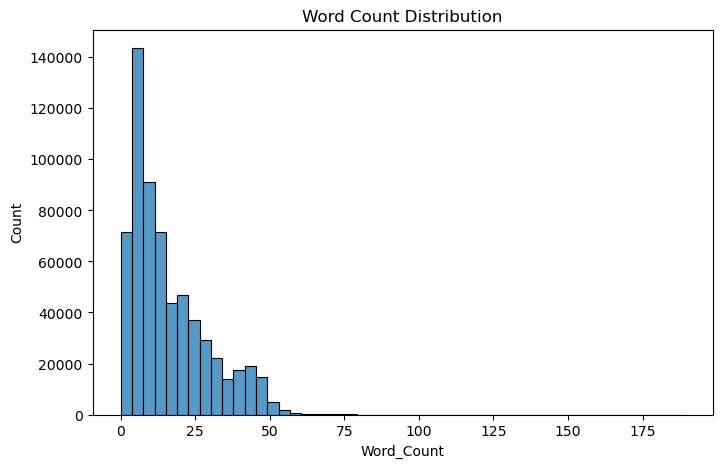

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Word_Count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

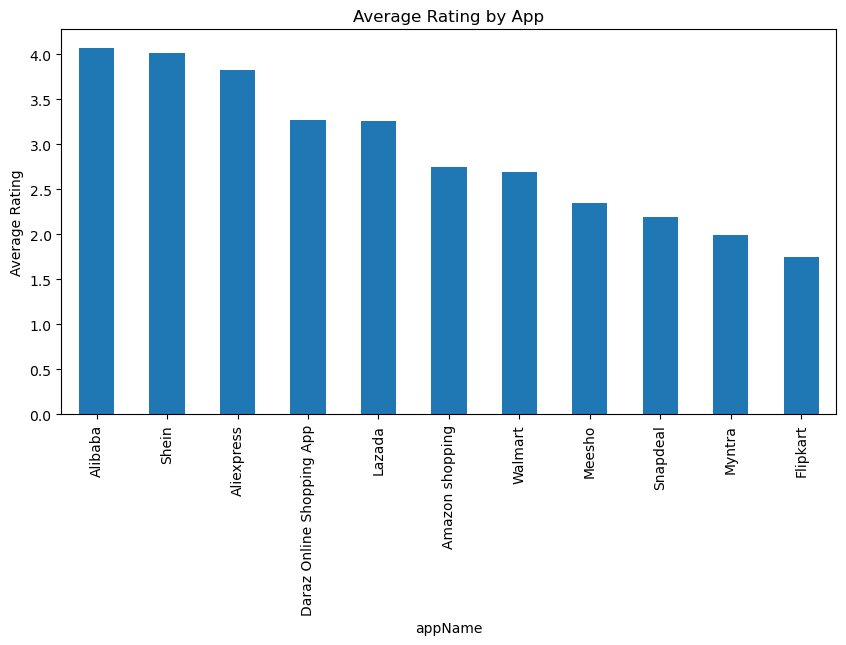

In [39]:
# Avarage Rating By App
avg_rating = df.groupby('appName')['score'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
avg_rating.plot(kind='bar')
plt.title("Average Rating by App")
plt.ylabel("Average Rating")
plt.show()

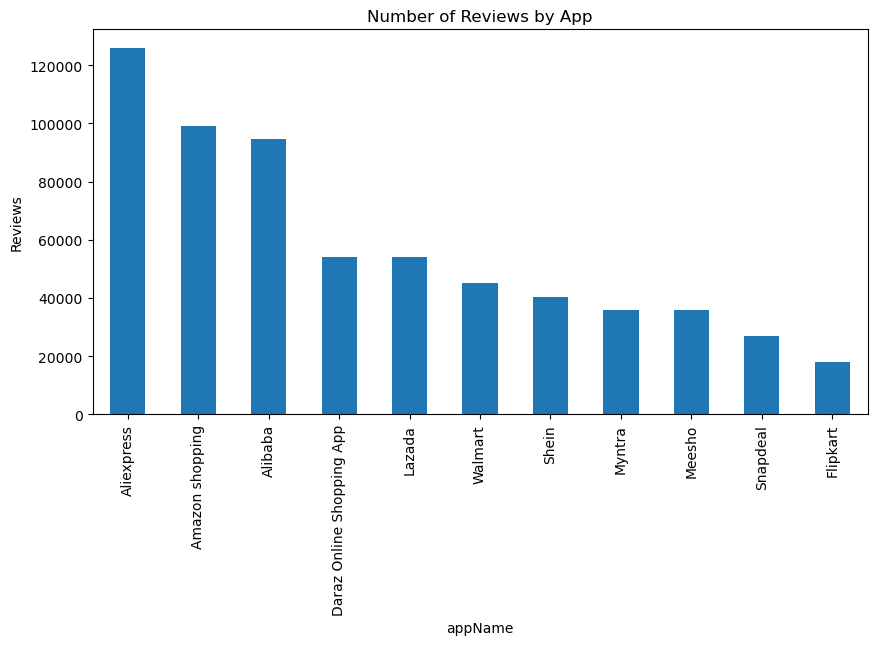

In [40]:
# Top Apps By Reviews
top_apps = df['appName'].value_counts()
plt.figure(figsize=(10,5))
top_apps.plot(kind='bar')
plt.title("Number of Reviews by App")
plt.ylabel("Reviews")
plt.show()

In [ ]:
# Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = " ".join(df['clean_review'].dropna())
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Overall Word Cloud")
plt.show()

In [ ]:
# Positive word Cloud
positive = " ".join(df[df['Sentiment']=="Positive"]['clean_review'])
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Greens'
).generate(positive)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

In [ ]:
# Negitive word cloud
negative = " ".join(df[df['Sentiment']=="Negative"]['clean_review'])
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Reds'
).generate(negative)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [ ]:
# Most Frequent Words
words = " ".join(df['clean_review']).split()
common_words = Counter(words).most_common(20)
common_df = pd.DataFrame(common_words, columns=['Word','Frequency'])
plt.figure(figsize=(12,6))
sns.barplot(data=common_df, x='Frequency', y='Word')
plt.title("Top 20 Most Frequent Words")
plt.show()

In [ ]:
df.to_csv("shopping_app_reviews_clean_data.csv", index=False)